For Nikos: We use the PLS pipeline to fit models that separate each basal cell perturbation from basal unperturbed cells.

We ensure that the Q2Y p-value is less than or equal to 0.05 for all PLS model fits. 

In [1]:
import os
from contextlib import contextmanager
import copy
import warnings
import sys
import math

from tqdm import trange, tqdm

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.insert(1, '../.')
from McCauley_utils import all_data

sys.path.insert(1, '../../.') 
from notebook_utils import get_split, clear_adata

sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import io
from scLEMBAS import latent_separation as ls

/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install

In [2]:
seed = 888
data_path = '/home/hmbaghda/orcd/pool/scLEMBAS/analysis'
author = 'McCauley'

n_cores = 30
os.environ["OMP_NUM_THREADS"] = str(1)
os.environ["MKL_NUM_THREADS"] = str(1)
os.environ["OPENBLAS_NUM_THREADS"] = str(1)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(1)
os.environ["NUMEXPR_NUM_THREADS"] = str(1)

In [3]:
(sn_ppis, tf_adata, adata, expr, source_label, target_label, weight_label, 
 stimulation_label, inhibition_label, cat_col, pert_col, ctrl_pert) = all_data


In [4]:
@contextmanager
def suppress_all_output():
    """
    Suppress stdout, stderr, warnings, tqdm, and most parallel chatter.
    """
    # save originals
    old_stdout = sys.stdout
    old_stderr = sys.stderr

    try:
        # redirect stdout / stderr
        sys.stdout = open(os.devnull, 'w')
        sys.stderr = open(os.devnull, 'w')

        # silence warnings
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")

            # silence tqdm globally
            os.environ["TQDM_DISABLE"] = "1"

            yield

    finally:
        # restore
        sys.stdout.close()
        sys.stderr.close()
        sys.stdout = old_stdout
        sys.stderr = old_stderr

        os.environ.pop("TQDM_DISABLE", None)

In [5]:
# as in Notebook 04
csw = {
    'max_components': 25 ,
    'metric': 'accuracy', 
    'method': 'elbow', 
    'n_folds': 5, 
    'seed': 888
}

assessment_kwargs = {
    'n_perm': 100, 
    'get_q2_pval': True, 
    'get_r2_pval': False, 
    'get_accuracy_pval': False,
    'n_folds': 5, 
    'seed': 888
}

def run_pls_(tf_adata_test, n_components = None):
    with suppress_all_output():
        models, X_pls = ls.pls_da(
            adata = tf_adata_test, 
            n_components = n_components, 
            assess = True, 
            enc_X = None, enc_Y = None, control_confounders = None, 
            separate_by = 'perturbation', 
            pert_col = pert_col, 
            cat_col = cat_col, 
            component_selection_kwargs = csw, 
            assessment_kwargs = assessment_kwargs, 
            n_cores = n_cores, 
            verbose = False
        )

    pls_model = models['pls_model']

    q2y_pval = pls_model.assessment_metrics['Q2Y']['pval']
    assert q2y_pval <= 0.05, 'The fit model is not significant for fold: {}'.format(fold)
    X_pls_transform = pls_model.transform(tf_adata_test.X)
    assert np.allclose(X_pls_transform, X_pls), 'Something is missing between model fit and transform'
    
    vip_scores = pd.DataFrame(
        data = {
            'vip_score': ls.compute_vip(pls_model), 
            'feature_name': tf_adata_test.var_names
        }
    )
    
    
    return pls_model, vip_scores

In [16]:
ct = 'Basal'
ctrl_cond = '^'.join([ct, ctrl_pert])

ct_mask = (tf_adata.obs[cat_col] == 'Basal')
perts = sorted(tf_adata.obs[ct_mask][pert_col].unique())
perts.remove(ctrl_pert)

vip_scores_all = []
pls_models = {}
for pert in tqdm(perts):
    pert_cond = '^'.join([ct, pert])
    counterfactual_mask = tf_adata.obs.condition.isin([pert_cond, ctrl_cond])
    tf_adata_sub = tf_adata[counterfactual_mask,:].copy() 
    
    pls_model, vip_scores = run_pls_(tf_adata_sub, n_components = None)
    
    pls_models[pert] = pls_model
    
    vip_scores['perturbation'] = pert
    vip_scores_all.append(vip_scores)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:51<00:00, 10.25s/it]


Perturbation: BMP4 | 4 components | Q2Y 0.785 (p = 9.90E-03)
Perturbation: IFNA2 | 2 components | Q2Y 0.886 (p = 9.90E-03)
Perturbation: IFNG | 5 components | Q2Y 0.944 (p = 9.90E-03)
Perturbation: IL13 | 5 components | Q2Y 0.848 (p = 9.90E-03)
Perturbation: TGFB1 | 5 components | Q2Y 0.912 (p = 9.90E-03)


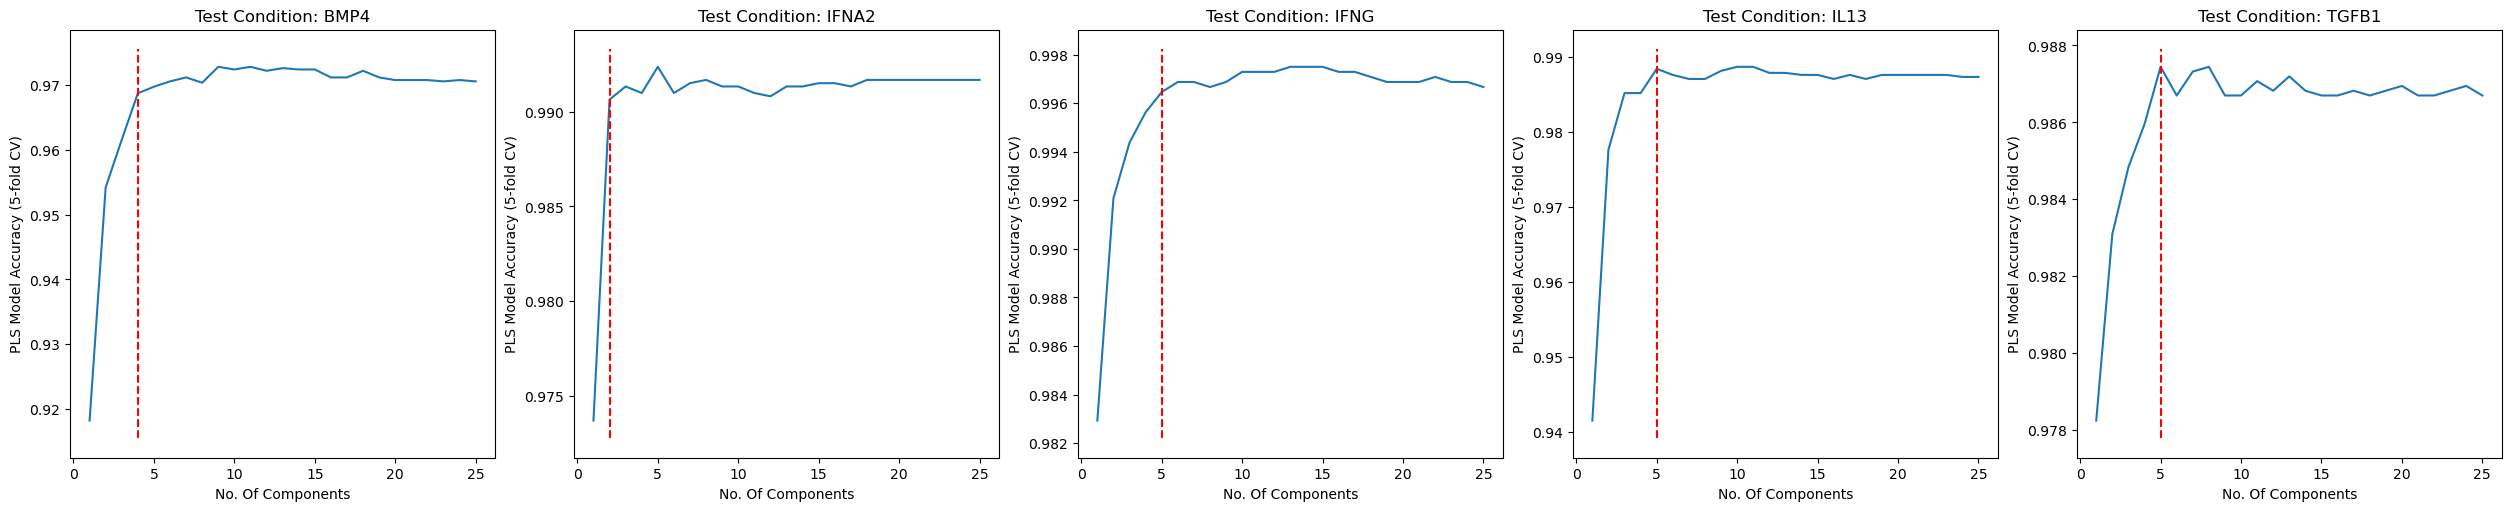

In [17]:
fig, ax = plt.subplots(ncols = 5, figsize = (25, 5), constrained_layout = True)

for (i, (test_cond, pls_model)) in enumerate(pls_models.items()):
    n_components = pls_model.n_components
    q2y = pls_model.assessment_metrics['Q2Y']['value']
    q2y_pval = pls_model.assessment_metrics['Q2Y']['pval']
    print('Perturbation: {} | {} components | Q2Y {:.3f} (p = {:.2E})'.format(test_cond, n_components, q2y, q2y_pval))
    
    
    sns.lineplot(y = pls_model.metric_per_component, x = range(1, len(pls_model.metric_per_component) + 1), ax = ax[i])
    ymin, ymax = ax[i].get_ylim()
    ax[i].vlines(x = pls_model.n_components, ymin = ymin, ymax = ymax, #label = 'Selected No. of Components',
              color = 'red', linestyle = '--'
             )
    ax[i].set_xlabel('No. Of Components')
    ax[i].set_ylabel('PLS Model Accuracy (5-fold CV)')
    ax[i].set_title('Test Condition: {}'.format(' '.join(test_cond.split('^'))))


In [20]:
vip_scores_all = pd.concat(vip_scores_all)
vip_scores_all.to_csv(os.path.join(data_path, 'interim', 'basal_perturbation_vip.csv'))